In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import interp1d

In [2]:
# File paths
MC_CCB_FILE = Path(r"C:\Users\grzanka\workspace\osl_mb_foils\notebooks\pub_something_2026\mc_ccb\mc_ccb.csv")
EBT_CCB_FILE = Path(r"C:\Users\grzanka\workspace\osl_mb_foils\notebooks\pub_something_2026\ebt_foils\ebt_profile_ccb.csv")

print(f"MC file exists: {MC_CCB_FILE.exists()}")
print(f"EBT file exists: {EBT_CCB_FILE.exists()}")

MC file exists: True
EBT file exists: True


In [3]:
# Load MC data
# Columns: depth (mm), dose (normalized), fluence, kinetic_energy
df_mc = pd.read_csv(MC_CCB_FILE)

# Load EBT data
# Columns: x_mm (mm, shifted so pencil mark is at X=0), dose_Gy (Gy)
df_ebt = pd.read_csv(EBT_CCB_FILE)

print("MC Data:")
print(df_mc.head())
print(f"Shape: {df_mc.shape}")
print(f"Depth range: [{df_mc['depth'].min():.2f}, {df_mc['depth'].max():.2f}] mm")
print()
print("EBT Data:")
print(df_ebt.head())
print(f"Shape: {df_ebt.shape}")
print(f"X range: [{df_ebt['x_mm'].min():.2f}, {df_ebt['x_mm'].max():.2f}] mm")

MC Data:
   depth      dose   fluence  kinetic_energy
0   0.05  0.259066  0.080329       60.459218
1   0.15  0.254962  0.079671       60.420271
2   0.25  0.252325  0.079104       60.347604
3   0.35  0.258469  0.080560       60.205106
4   0.45  0.255408  0.079773       60.070364
Shape: (320, 4)
Depth range: [0.05, 31.95] mm

EBT Data:
        x_mm   dose_Gy
0 -12.136225  0.121226
1 -11.966892  0.131299
2 -11.797558  0.137988
3 -11.628225  0.144432
4 -11.458892  0.145763
Shape: (264, 2)
X range: [-12.14, 32.40] mm


In [4]:
# Rescale MC dose to match EBT dose at X = 0 mm
# First, interpolate both datasets at X = 0

# EBT interpolation at X = 0
ebt_interp = interp1d(df_ebt['x_mm'], df_ebt['dose_Gy'], kind='linear', fill_value='extrapolate')
ebt_dose_at_0 = float(ebt_interp(0))

# MC interpolation at X = 0 (using depth column which corresponds to x position)
mc_interp = interp1d(df_mc['depth'], df_mc['dose'], kind='linear', fill_value='extrapolate')
mc_dose_at_0 = float(mc_interp(0))

# Calculate scaling factor
scale_factor = ebt_dose_at_0 / mc_dose_at_0

print(f"EBT dose at X=0: {ebt_dose_at_0:.4f} Gy")
print(f"MC dose at X=0 (normalized): {mc_dose_at_0:.4f}")
print(f"Scale factor: {scale_factor:.4f}")

# Create scaled MC dose column
df_mc['dose_scaled'] = df_mc['dose'] * scale_factor
print(f"\nMC dose at X=0 after scaling: {float(mc_interp(0)) * scale_factor:.4f} Gy")

EBT dose at X=0: 5.0339 Gy
MC dose at X=0 (normalized): 0.2611
Scale factor: 19.2784

MC dose at X=0 after scaling: 5.0339 Gy


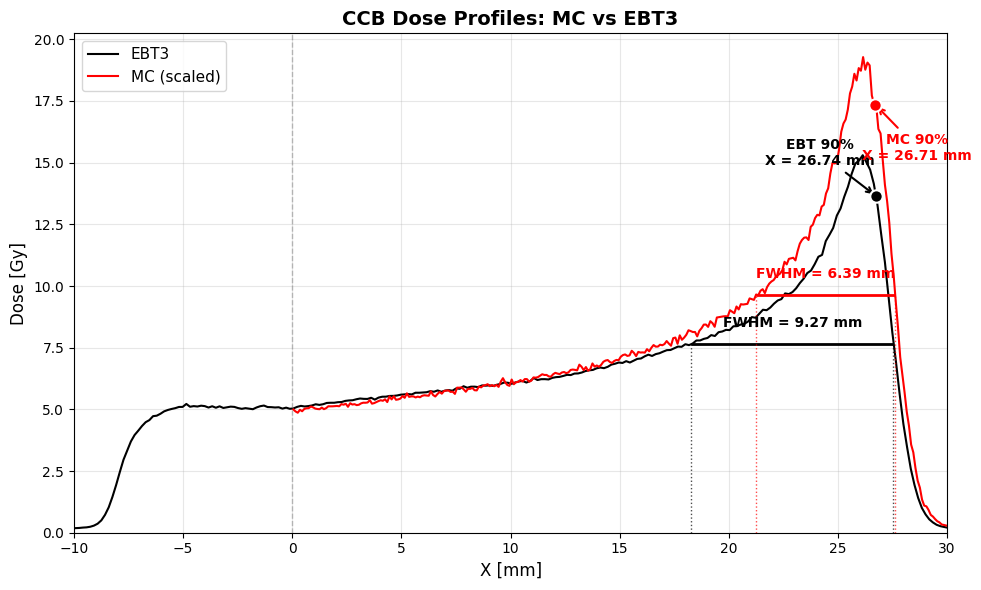

In [8]:
# Plot MC and EBT dose profiles on the same plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot EBT data (black color)
ax.plot(df_ebt['x_mm'], df_ebt['dose_Gy'], 
        color='black', linewidth=1.5, label='EBT3')

# Plot MC data (scaled, red color)
ax.plot(df_mc['depth'], df_mc['dose_scaled'], 
        color='red', linewidth=1.5, label='MC (scaled)')

# Mark the reference point at X=0
ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Create dense grids for interpolation
x_dense = np.linspace(df_ebt['x_mm'].min(), df_ebt['x_mm'].max(), 1000)
ebt_dense = ebt_interp(x_dense)

mc_interp_scaled = interp1d(df_mc['depth'], df_mc['dose_scaled'], kind='linear', fill_value='extrapolate')
x_dense_mc = np.linspace(df_mc['depth'].min(), df_mc['depth'].max(), 1000)
mc_dense = mc_interp_scaled(x_dense_mc)

# --- FWHM for EBT ---
ebt_max = df_ebt['dose_Gy'].max()
ebt_half_max = ebt_max / 2

above_half_ebt = ebt_dense >= ebt_half_max
transitions_ebt = np.diff(above_half_ebt.astype(int))
rising_idx_ebt = np.where(transitions_ebt == 1)[0]
falling_idx_ebt = np.where(transitions_ebt == -1)[0]

if len(rising_idx_ebt) > 0 and len(falling_idx_ebt) > 0:
    fwhm_left_ebt = x_dense[rising_idx_ebt[0]]
    fwhm_right_ebt = x_dense[falling_idx_ebt[-1]]
    fwhm_value_ebt = fwhm_right_ebt - fwhm_left_ebt
    
    # Draw FWHM horizontal line for EBT
    ax.hlines(y=ebt_half_max, xmin=fwhm_left_ebt, xmax=fwhm_right_ebt, 
              colors='black', linestyles='-', linewidth=2)
    ax.vlines(x=[fwhm_left_ebt, fwhm_right_ebt], ymin=0, ymax=ebt_half_max, 
              colors='black', linestyles=':', linewidth=1, alpha=0.7)
    ax.annotate(f'FWHM = {fwhm_value_ebt:.2f} mm', 
                xy=((fwhm_left_ebt + fwhm_right_ebt) / 2, ebt_half_max),
                xytext=(0, 10), textcoords='offset points',
                ha='center', va='bottom', fontsize=10, color='black',
                fontweight='bold')

# --- FWHM for MC ---
mc_max = df_mc['dose_scaled'].max()
mc_half_max = mc_max / 2

above_half_mc = mc_dense >= mc_half_max
transitions_mc = np.diff(above_half_mc.astype(int))
rising_idx_mc = np.where(transitions_mc == 1)[0]
falling_idx_mc = np.where(transitions_mc == -1)[0]

if len(rising_idx_mc) > 0 and len(falling_idx_mc) > 0:
    fwhm_left_mc = x_dense_mc[rising_idx_mc[0]]
    fwhm_right_mc = x_dense_mc[falling_idx_mc[-1]]
    fwhm_value_mc = fwhm_right_mc - fwhm_left_mc
    
    # Draw FWHM horizontal line for MC
    ax.hlines(y=mc_half_max, xmin=fwhm_left_mc, xmax=fwhm_right_mc, 
              colors='red', linestyles='-', linewidth=2)
    ax.vlines(x=[fwhm_left_mc, fwhm_right_mc], ymin=0, ymax=mc_half_max, 
              colors='red', linestyles=':', linewidth=1, alpha=0.7)
    ax.annotate(f'FWHM = {fwhm_value_mc:.2f} mm', 
                xy=((fwhm_left_mc + fwhm_right_mc) / 2, mc_half_max),
                xytext=(0, 10), textcoords='offset points',
                ha='center', va='bottom', fontsize=10, color='red',
                fontweight='bold')

# --- Find 90% dose point on distal part for EBT (relative to max dose) ---
dose_90_ebt = 0.9 * ebt_max

# Find position of max dose for EBT
idx_max_ebt = np.argmax(ebt_dense)
x_max_ebt = x_dense[idx_max_ebt]

# Look only in distal part (X > position of max)
distal_mask_ebt = x_dense > x_max_ebt
x_distal_ebt = x_dense[distal_mask_ebt]
ebt_distal = ebt_dense[distal_mask_ebt]

below_90_ebt = ebt_distal < dose_90_ebt
if np.any(below_90_ebt):
    idx_90_ebt = np.where(below_90_ebt)[0][0]
    x_90_ebt = x_distal_ebt[idx_90_ebt]
    dose_at_90_ebt = ebt_distal[idx_90_ebt]
    
    ax.scatter([x_90_ebt], [dose_at_90_ebt], color='black', s=80, zorder=5, marker='o', edgecolors='white', linewidths=1.5)
    ax.annotate(f'EBT 90%\nX = {x_90_ebt:.2f} mm', 
                xy=(x_90_ebt, dose_at_90_ebt),
                xytext=(-40, 20), textcoords='offset points',
                ha='center', va='bottom', fontsize=10, color='black',
                fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# --- Find 90% dose point on distal part for MC (relative to max dose) ---
dose_90_mc = 0.9 * mc_max

# Find position of max dose for MC
idx_max_mc = np.argmax(mc_dense)
x_max_mc = x_dense_mc[idx_max_mc]

# Look only in distal part (X > position of max)
distal_mask_mc = x_dense_mc > x_max_mc
x_distal_mc = x_dense_mc[distal_mask_mc]
mc_distal = mc_dense[distal_mask_mc]

below_90_mc = mc_distal < dose_90_mc
if np.any(below_90_mc):
    idx_90_mc = np.where(below_90_mc)[0][0]
    x_90_mc = x_distal_mc[idx_90_mc]
    dose_at_90_mc = mc_distal[idx_90_mc]
    
    ax.scatter([x_90_mc], [dose_at_90_mc], color='red', s=80, zorder=5, marker='o', edgecolors='white', linewidths=1.5)
    ax.annotate(f'MC 90%\nX = {x_90_mc:.2f} mm', 
                xy=(x_90_mc, dose_at_90_mc),
                xytext=(30, -20), textcoords='offset points',
                ha='center', va='top', fontsize=10, color='red',
                fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

ax.set_xlabel('X [mm]', fontsize=12)
ax.set_ylabel('Dose [Gy]', fontsize=12)
ax.set_title('CCB Dose Profiles: MC vs EBT3', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(-10, 30)
ax.set_ylim(0, None)

plt.tight_layout()
plt.show()